# 17 Long-Memory Citation-Flow Analysis

## Setup

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

cwd = Path.cwd()
PROJECT_ROOT = cwd.parent if cwd.name == "notebooks" else cwd
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

NOTEBOOK_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "17_long_memory_citation_flow"
FIGURE_DIR = NOTEBOOK_OUTPUT_DIR / "figures"
TABLE_DIR = NOTEBOOK_OUTPUT_DIR / "tables"
DATA_OUTPUT_DIR = NOTEBOOK_OUTPUT_DIR / "data"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)
DATA_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

GENDER_CATEGORIES = ["MM", "MW", "WM", "WW"]

pd.set_option("display.max_columns", 120)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

## Functions

In [2]:
def standardize_edges(edges):
    out = edges[["citing_paper_id", "cited_paper_id"]].copy()
    out["citing_paper_id"] = out["citing_paper_id"].astype(str)
    out["cited_paper_id"] = out["cited_paper_id"].astype(str)
    return out

def load_final_core():
    papers = pd.read_pickle(PROCESSED_DIR / "papers_final.pkl")
    cs_papers = pd.read_pickle(PROCESSED_DIR / "cs_papers_final.pkl")
    all_edges = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_final.pkl"))
    all_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_all_to_cs_final.pkl"))
    cs_to_cs = standardize_edges(pd.read_pickle(PROCESSED_DIR / "citation_edges_cs_to_cs_final.pkl"))
    papers["id"] = papers["id"].astype(str)
    cs_papers["id"] = cs_papers["id"].astype(str)
    return papers, cs_papers, all_edges, all_to_cs, cs_to_cs

def known_cs(cs_papers):
    return cs_papers[cs_papers["first_last_cat"].isin(GENDER_CATEGORIES)].copy()

def aggregate_oe(observed, expected, baseline, citation_slice):
    rows = []
    for g in GENDER_CATEGORIES:
        o = float(observed.get(g, 0.0))
        e = float(expected.get(g, 0.0))
        oe = o / e if e > 0 else np.nan
        rows.append({
            "gender_cat": g,
            "observed_citations": o,
            "expected_citations": e,
            "oe_ratio": oe,
            "pct_diff_from_expected": (oe - 1.0) * 100 if pd.notna(oe) else np.nan,
            "baseline": baseline,
            "citation_slice": citation_slice,
        })
    return pd.DataFrame(rows)

def enrich_lag(edges, year_map, cited_meta):
    x = edges.copy()
    x["citing_year"] = x["citing_paper_id"].map(year_map)
    x = x.merge(cited_meta, on="cited_paper_id", how="inner")
    x = x.dropna(subset=["citing_year", "cited_year"]).copy()
    x["citing_year"] = x["citing_year"].astype(int)
    x["cited_year"] = x["cited_year"].astype(int)
    x["lag"] = x["citing_year"] - x["cited_year"]
    x = x[x["lag"].ge(0)].copy()
    x["fine_bucket"] = np.select(
        [
            x["lag"].between(0, 2),
            x["lag"].between(3, 5),
            x["lag"].between(6, 10),
            x["lag"].between(11, 20),
            x["lag"].gt(20),
        ],
        ["0-2", "3-5", "6-10", "11-20", "20+"],
        default=None,
    )
    x["memory_group"] = np.select(
        [
            x["lag"].between(0, 5),
            x["lag"].between(6, 10),
            x["lag"].gt(10),
        ],
        ["short", "middle", "long"],
        default=None,
    )
    return x

def eligibility_table(citing_years, bounds, label_col, paper_year_counts):
    rows = []
    for y in sorted(set(map(int, citing_years))):
        for label, (lo, hi) in bounds.items():
            if hi is None:
                z = paper_year_counts[paper_year_counts["year"].le(y - lo)]
            else:
                z = paper_year_counts[paper_year_counts["year"].between(y - hi, y - lo)]
            counts = z.groupby("first_last_cat")["n"].sum().reindex(GENDER_CATEGORIES, fill_value=0)
            total = counts.sum()
            row = {"citing_year": y, label_col: label}
            for g in GENDER_CATEGORIES:
                row[g] = counts[g] / total if total else np.nan
            rows.append(row)
    return pd.DataFrame(rows)

def summarize_lag(x, group_col, bounds, citation_slice, paper_year_counts):
    shares = eligibility_table(x["citing_year"].unique(), bounds, group_col, paper_year_counts)
    z = x.merge(shares, on=["citing_year", group_col], how="left")
    pieces = []
    for grp, q in z.groupby(group_col, dropna=False):
        obs = q["cited_gender"].value_counts().reindex(GENDER_CATEGORIES, fill_value=0)
        exp = q[GENDER_CATEGORIES].sum().reindex(GENDER_CATEGORIES, fill_value=0)
        out = aggregate_oe(obs, exp, f"long_memory_{group_col}", citation_slice)
        out[group_col] = grp
        out["n_edges"] = len(q)
        pieces.append(out)
    return pd.concat(pieces, ignore_index=True), z

## Compute Lag Groups

In [3]:
papers, cs_papers, citation_edges_final, edges_all_to_cs, edges_cs_to_cs = load_final_core()
cs_known = known_cs(cs_papers)

year_map = papers.set_index("id")["year"]
cited_meta = cs_known[["id", "year", "first_last_cat"]].rename(
    columns={"id": "cited_paper_id", "year": "cited_year", "first_last_cat": "cited_gender"}
)

paper_year_counts = (
    cs_known.dropna(subset=["year"])
    .assign(year=lambda d: d["year"].astype(int))
    .groupby(["year", "first_last_cat"])
    .size()
    .rename("n")
    .reset_index()
)

FINE_BOUNDS = {
    "0-2": (0, 2),
    "3-5": (3, 5),
    "6-10": (6, 10),
    "11-20": (11, 20),
    "20+": (21, None),
}
MEM_BOUNDS = {
    "short": (0, 5),
    "middle": (6, 10),
    "long": (11, None),
}

all_lag = enrich_lag(edges_all_to_cs, year_map, cited_meta)
cs_lag = enrich_lag(edges_cs_to_cs, year_map, cited_meta)

fine_all, fine_all_edges = summarize_lag(
    all_lag, "fine_bucket", FINE_BOUNDS, "All→CS", paper_year_counts
)
fine_cs, fine_cs_edges = summarize_lag(
    cs_lag, "fine_bucket", FINE_BOUNDS, "CS→CS", paper_year_counts
)
mem_all, mem_all_edges = summarize_lag(
    all_lag, "memory_group", MEM_BOUNDS, "All→CS", paper_year_counts
)
mem_cs, mem_cs_edges = summarize_lag(
    cs_lag, "memory_group", MEM_BOUNDS, "CS→CS", paper_year_counts
)

fine = pd.concat([fine_all, fine_cs], ignore_index=True)
memory = pd.concat([mem_all, mem_cs], ignore_index=True)

display(memory)

,gender_cat,observed_citations,expected_citations,oe_ratio,pct_diff_from_expected,baseline,citation_slice,memory_group,n_edges
0,MM,"2,172,851.0000","2,110,464.1881",1.0296,2.9561,long_memory_memory_group,All→CS,long,2557602
1,MW,"140,128.0000","149,837.7222",0.9352,-6.4802,long_memory_memory_group,All→CS,long,2557602
2,WM,"167,405.0000","181,652.1421",0.9216,-7.8431,long_memory_memory_group,All→CS,long,2557602
3,WW,"77,218.0000","115,647.9476",0.6677,-33.2301,long_memory_memory_group,All→CS,long,2557602
4,MM,"1,869,920.0000","1,797,266.0831",1.0404,4.0425,long_memory_memory_group,All→CS,middle,2338119
5,MW,"177,786.0000","185,404.9165",0.9589,-4.1093,long_memory_memory_group,All→CS,middle,2338119
6,WM,"215,998.0000","246,251.3542",0.8771,-12.2856,long_memory_memory_group,All→CS,middle,2338119
7,WW,"74,415.0000","109,196.6463",0.6815,-31.8523,long_memory_memory_group,All→CS,middle,2338119
8,MM,"2,899,882.0000","2,776,040.9719",1.0446,4.4611,long_memory_memory_group,All→CS,short,3790516
9,MW,"323,521.0000","341,581.2895",0.9471,-5.2873,long_memory_memory_group,All→CS,short,3790516


## Figures

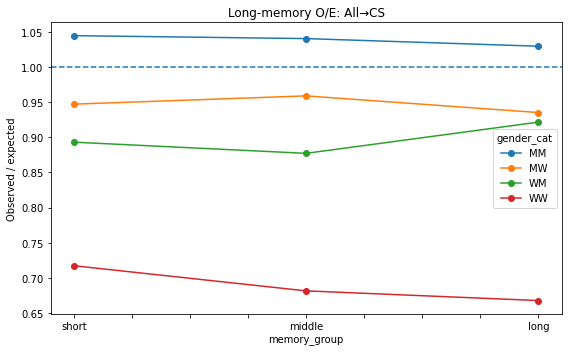

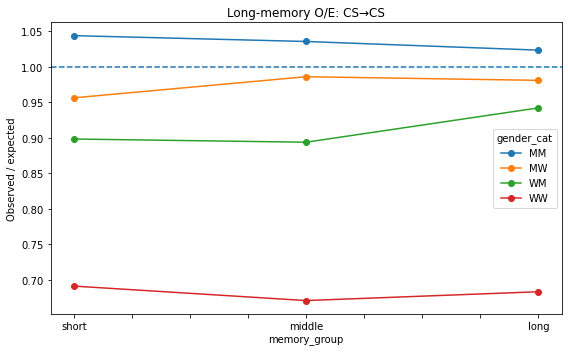

In [4]:
for sl in ["All→CS", "CS→CS"]:
    z = memory[memory["citation_slice"].eq(sl)]
    piv = (
        z.pivot(index="memory_group", columns="gender_cat", values="oe_ratio")
        .reindex(["short", "middle", "long"])
    )
    ax = piv.plot(marker="o", figsize=(8, 5))
    ax.axhline(1, linestyle="--")
    ax.set_ylabel("Observed / expected")
    ax.set_title(f"Long-memory O/E: {sl}")
    plt.tight_layout()
    safe = sl.replace("→", "_to_")
    plt.savefig(FIGURE_DIR / f"long_memory_oe_{safe}.png", dpi=300, bbox_inches="tight")
    plt.show()

## Save Results

In [5]:
fine.to_csv(TABLE_DIR / "long_memory_fine_lag_oe_by_gender.csv", index=False)
memory.to_csv(TABLE_DIR / "long_memory_memory_group_oe_by_gender.csv", index=False)
pd.DataFrame({
    "slice": ["All→CS", "CS→CS"],
    "valid_lag_edges": [len(all_lag), len(cs_lag)],
}).to_csv(TABLE_DIR / "long_memory_edge_coverage.csv", index=False)